# Proyecto Final - Clasificación y Agrupación

**Curso:** Machine Learning 1  
**Estudiante:** Joseph Mora  

## Objetivo

El objetivo de este proyecto es aplicar técnicas de Machine Learning sobre un conjunto de datos de clientes bancarios.

Se implementarán dos modelos de clasificación que serán sometidos a comparación mediante diferentes métricas de evaluación, con el propósito de seleccionar el modelo que presente el mejor desempeño para realizar predicciones.

Además, se implementará un modelo de agrupación que permita identificar diferentes perfiles de clientes de acuerdo con sus características financieras y crediticias.

Finalmente, se aplicará el mejor modelo de clasificación y el modelo de agrupación a un nuevo cliente para observar su predicción y el grupo al cual pertenece.

# > Carga de datos

## >> Importación de librerías y bibliotecas

En esta sección se importan las principales librerías que serán utilizadas durante el desarrollo del proyecto para la manipulación de datos, visualización y construcción de los modelos de Machine Learning.

In [5]:
# Librerías para manejo de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# División de datos
from sklearn.model_selection import train_test_split

# Escalado de datos
from sklearn.preprocessing import StandardScaler

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Modelo de agrupación
from sklearn.cluster import KMeans

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Evitar mensajes de advertencia innecesarios
import warnings
warnings.filterwarnings("ignore")

## >> Carga del archivo

Se procede a cargar el conjunto de datos `clientes_banco(1).xlsx`, el cual contiene información financiera y crediticia de clientes bancarios.

Este conjunto de datos será utilizado para realizar el análisis exploratorio, entrenar los modelos de clasificación y posteriormente generar los grupos de clientes mediante un modelo de agrupación.

In [6]:
from google.colab import files

archivo = files.upload()

Saving clientes_banco(1).xlsx to clientes_banco(1) (1).xlsx


In [7]:
# Cargar el archivo Excel

df_clientes = pd.read_excel("clientes_banco(1).xlsx")

# Mostrar los primeros registros
df_clientes.head()

,edad,ingreso_mensual,antiguedad_cliente_meses,cantidad_tarjetas_activas,deuda_total,porcentaje_uso_credito,cantidad_pagos_atrasados_historicos,score_crediticio,cantidad_productos_bancarios,gasto_mensual_promedio,cantidad_consultas_credito_ultimo_anio,linea_credito_aprobada,mora
0,44,2281997.51,134,3,764332.08,11.25,0,734,2,1331240.76,2,8046000,0
1,18,582019.75,96,1,1762867.69,51.69,2,538,4,894067.07,5,2429000,0
2,50,457705.57,39,4,2607589.34,92.45,7,447,1,78899.15,0,1300000,1
3,42,1951105.56,83,5,1838059.21,32.64,1,818,1,NaN,1,6905000,0
4,40,1614834.45,80,3,1767812.29,13.98,0,738,5,284712.77,1,5333000,0


# > Comprensión de los datos

Antes de realizar la limpieza y aplicar los modelos de Machine Learning, es necesario conocer las características principales del conjunto de datos.

En esta sección se analizará:

- La cantidad de registros y variables.
- Los nombres de las columnas.
- Los tipos de datos.
- Los valores nulos.
- Los registros duplicados.
- Algunos valores únicos de las variables.

Esto permitirá identificar posibles problemas que deban ser corregidos antes del entrenamiento de los modelos.

## >> Dimensiones del conjunto de datos

Se utiliza `shape` para conocer la cantidad total de filas y columnas que contiene el conjunto de datos.

In [8]:
# Cantidad de filas y columnas

df_clientes.shape

(5500, 13)

In [9]:
# Mostrar cantidad de registros y variables

print("Cantidad de registros:", df_clientes.shape[0])
print("Cantidad de variables:", df_clientes.shape[1])

Cantidad de registros: 5500
Cantidad de variables: 13


## >> Primeros registros

Se muestran los primeros registros del conjunto de datos para conocer de forma general las variables disponibles y los valores almacenados en cada una de ellas.

## >> Nombres de las variables

Se muestran los nombres de todas las columnas disponibles en el conjunto de datos.

In [10]:
# Nombres de las columnas

df_clientes.columns

Index(['edad', 'ingreso_mensual', 'antiguedad_cliente_meses',
       'cantidad_tarjetas_activas', 'deuda_total', 'porcentaje_uso_credito',
       'cantidad_pagos_atrasados_historicos', 'score_crediticio',
       'cantidad_productos_bancarios', 'gasto_mensual_promedio',
       'cantidad_consultas_credito_ultimo_anio', 'linea_credito_aprobada',
       'mora'],
      dtype='object')

## >> Información general

La función `info()` permite observar el número de registros no nulos y el tipo de dato correspondiente a cada variable.

In [11]:
# Información general del DataFrame

df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   edad                                    5500 non-null   int64  
 1   ingreso_mensual                         5148 non-null   float64
 2   antiguedad_cliente_meses                5500 non-null   int64  
 3   cantidad_tarjetas_activas               5500 non-null   int64  
 4   deuda_total                             5153 non-null   float64
 5   porcentaje_uso_credito                  5146 non-null   float64
 6   cantidad_pagos_atrasados_historicos     5500 non-null   int64  
 7   score_crediticio                        5500 non-null   int64  
 8   cantidad_productos_bancarios            5500 non-null   int64  
 9   gasto_mensual_promedio                  5151 non-null   float64
 10  cantidad_consultas_credito_ultimo_anio  5500 non-null   int6

## >> Tipos de datos

Se verifican los tipos de datos de cada variable para determinar si existen columnas que requieran alguna transformación antes de realizar el análisis y el entrenamiento de los modelos.

In [12]:
# Tipos de datos de las variables

df_clientes.dtypes

,0
edad,int64
ingreso_mensual,float64
antiguedad_cliente_meses,int64
cantidad_tarjetas_activas,int64
deuda_total,float64
porcentaje_uso_credito,float64
cantidad_pagos_atrasados_historicos,int64
score_crediticio,int64
cantidad_productos_bancarios,int64
gasto_mensual_promedio,float64


# > Limpieza de datos

## >> Valores nulos

Los valores nulos representan datos faltantes dentro del conjunto de datos.

Es importante identificarlos y tratarlos antes del entrenamiento de los modelos, ya que algunos algoritmos de Machine Learning no pueden trabajar directamente con valores faltantes.

In [13]:
# Verificar cantidad de valores nulos por columna

df_clientes.isnull().sum()

,0
edad,0
ingreso_mensual,352
antiguedad_cliente_meses,0
cantidad_tarjetas_activas,0
deuda_total,347
porcentaje_uso_credito,354
cantidad_pagos_atrasados_historicos,0
score_crediticio,0
cantidad_productos_bancarios,0
gasto_mensual_promedio,349


In [14]:
# Cantidad y porcentaje de valores nulos

nulos = pd.DataFrame({
    "Cantidad_Nulos": df_clientes.isnull().sum(),
    "Porcentaje_Nulos": (df_clientes.isnull().sum() / len(df_clientes)) * 100
})

nulos

,Cantidad_Nulos,Porcentaje_Nulos
edad,0,0.000000
ingreso_mensual,352,6.400000
antiguedad_cliente_meses,0,0.000000
cantidad_tarjetas_activas,0,0.000000
deuda_total,347,6.309091
porcentaje_uso_credito,354,6.436364
cantidad_pagos_atrasados_historicos,0,0.000000
score_crediticio,0,0.000000
cantidad_productos_bancarios,0,0.000000
gasto_mensual_promedio,349,6.345455


## >> Tratamiento de valores nulos

Debido a que las variables que presentan valores faltantes son numéricas, se utilizará la mediana para reemplazar dichos valores.

La mediana es una medida adecuada porque es menos sensible a valores extremos que la media, permitiendo conservar todos los registros disponibles sin eliminar clientes del conjunto de datos.

In [15]:
# Identificar las columnas numéricas que contienen valores nulos

columnas_con_nulos = df_clientes.columns[df_clientes.isnull().any()]

columnas_con_nulos

Index(['ingreso_mensual', 'deuda_total', 'porcentaje_uso_credito',
       'gasto_mensual_promedio'],
      dtype='object')

In [16]:
# Reemplazar los valores nulos de variables numéricas por la mediana

for columna in columnas_con_nulos:
    if df_clientes[columna].dtype in ["int64", "float64"]:
        df_clientes[columna] = df_clientes[columna].fillna(
            df_clientes[columna].median()
        )

## >> Verificación posterior al tratamiento de nulos

Después de realizar la imputación, se verifica nuevamente la cantidad de valores nulos con el objetivo de comprobar que el procedimiento se realizó correctamente.

In [17]:
# Verificar nuevamente los valores nulos

df_clientes.isnull().sum()

,0
edad,0
ingreso_mensual,0
antiguedad_cliente_meses,0
cantidad_tarjetas_activas,0
deuda_total,0
porcentaje_uso_credito,0
cantidad_pagos_atrasados_historicos,0
score_crediticio,0
cantidad_productos_bancarios,0
gasto_mensual_promedio,0


## >> Datos duplicados

Los registros duplicados pueden generar una representación repetida de determinados clientes y afectar los resultados del análisis y de los modelos de Machine Learning.

Por esta razón, se verifica la cantidad de filas completamente duplicadas.

In [18]:
# Cantidad de registros duplicados

df_clientes.duplicated().sum()

np.int64(500)

## >> Eliminación de registros duplicados

Los registros completamente duplicados serán eliminados para evitar que la misma información tenga una mayor influencia durante el entrenamiento de los modelos.

In [19]:
# Eliminar registros duplicados

df_clientes = df_clientes.drop_duplicates()

# Reiniciar el índice
df_clientes = df_clientes.reset_index(drop=True)

print("Cantidad de registros después de eliminar duplicados:",
      df_clientes.shape[0])

Cantidad de registros después de eliminar duplicados: 5000


## >> Verificación de la limpieza

Después de tratar los valores nulos y eliminar los registros duplicados, se realiza una verificación final del conjunto de datos antes de continuar con el análisis estadístico y gráfico.

In [20]:
# Verificación final

print("Dimensiones finales:", df_clientes.shape)
print()
print("Cantidad total de valores nulos:", df_clientes.isnull().sum().sum())
print("Cantidad de registros duplicados:", df_clientes.duplicated().sum())

Dimensiones finales: (5000, 13)

Cantidad total de valores nulos: 0
Cantidad de registros duplicados: 0


In [21]:
# Mostrar los primeros registros después de la limpieza

df_clientes.head()

,edad,ingreso_mensual,antiguedad_cliente_meses,cantidad_tarjetas_activas,deuda_total,porcentaje_uso_credito,cantidad_pagos_atrasados_historicos,score_crediticio,cantidad_productos_bancarios,gasto_mensual_promedio,cantidad_consultas_credito_ultimo_anio,linea_credito_aprobada,mora
0,44,2281997.51,134,3,764332.08,11.25,0,734,2,1331240.76,2,8046000,0
1,18,582019.75,96,1,1762867.69,51.69,2,538,4,894067.07,5,2429000,0
2,50,457705.57,39,4,2607589.34,92.45,7,447,1,78899.15,0,1300000,1
3,42,1951105.56,83,5,1838059.21,32.64,1,818,1,447197.52,1,6905000,0
4,40,1614834.45,80,3,1767812.29,13.98,0,738,5,284712.77,1,5333000,0


### Interpretación de la limpieza de datos

Se realizó una revisión general del conjunto de datos para identificar posibles problemas de calidad.

Los valores faltantes de las variables numéricas fueron reemplazados utilizando la mediana y los registros completamente duplicados fueron eliminados.

Después de estos procedimientos, el conjunto de datos queda preparado para continuar con las estadísticas descriptivas, el análisis gráfico, el análisis de correlación y posteriormente la construcción de los modelos de Machine Learning.

# > Estadísticas descriptivas

Las estadísticas descriptivas permiten conocer las principales características de las variables presentes en el conjunto de datos.

Se analizarán medidas como la media, desviación estándar, valores mínimos, máximos y cuartiles. Esto permite obtener una primera visión del comportamiento financiero y crediticio de los clientes.

In [22]:
# Estadísticas descriptivas de las variables numéricas

df_clientes.describe()

,edad,ingreso_mensual,antiguedad_cliente_meses,cantidad_tarjetas_activas,deuda_total,porcentaje_uso_credito,cantidad_pagos_atrasados_historicos,score_crediticio,cantidad_productos_bancarios,gasto_mensual_promedio,cantidad_consultas_credito_ultimo_anio,linea_credito_aprobada,mora
count,5000.000000,5.000000e+03,5000.00000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.00000,5.000000e+03,5000.000000,5.000000e+03,5000.000000
mean,40.500800,9.746397e+05,46.51560,2.671600,1.496628e+06,45.526500,2.283200,639.091600,2.74200,5.099884e+05,2.515200,3.733565e+06,0.180000
std,10.956058,6.031964e+05,38.10114,1.323066,9.160572e+05,24.556411,2.669311,106.393789,1.43967,2.904384e+05,1.939722,2.079388e+06,0.384226
min,18.000000,2.500000e+05,1.00000,1.000000,0.000000e+00,0.000000,0.000000,326.000000,1.00000,0.000000e+00,0.000000,1.500000e+05,0.000000
25%,33.000000,5.539388e+05,14.00000,2.000000,6.187140e+05,25.460000,0.000000,561.000000,2.00000,3.124078e+05,1.000000,2.120000e+06,0.000000
50%,40.000000,7.695602e+05,38.00000,2.000000,1.530287e+06,42.385000,1.000000,639.000000,2.00000,4.471975e+05,2.000000,3.310500e+06,0.000000
75%,48.000000,1.153940e+06,69.00000,4.000000,2.104587e+06,64.815000,4.000000,725.000000,4.00000,6.410811e+05,4.000000,4.946250e+06,0.000000
max,75.000000,3.211935e+06,191.00000,5.000000,4.703740e+06,100.000000,15.000000,850.000000,6.00000,2.019141e+06,12.000000,1.008100e+07,1.000000


## >> Resumen de las principales variables

Para facilitar la interpretación, se muestran algunas de las principales medidas estadísticas como la media, mediana, desviación estándar, mínimo y máximo.

In [23]:
# Resumen estadístico

resumen_estadistico = df_clientes.describe().T

resumen_estadistico[["mean", "50%", "std", "min", "max"]]

,mean,50%,std,min,max
edad,4.050080e+01,40.000,1.095606e+01,18.0,75.00
ingreso_mensual,9.746397e+05,769560.150,6.031964e+05,250000.0,3211935.36
antiguedad_cliente_meses,4.651560e+01,38.000,3.810114e+01,1.0,191.00
cantidad_tarjetas_activas,2.671600e+00,2.000,1.323066e+00,1.0,5.00
deuda_total,1.496628e+06,1530286.990,9.160572e+05,0.0,4703740.46
porcentaje_uso_credito,4.552650e+01,42.385,2.455641e+01,0.0,100.00
cantidad_pagos_atrasados_historicos,2.283200e+00,1.000,2.669311e+00,0.0,15.00
score_crediticio,6.390916e+02,639.000,1.063938e+02,326.0,850.00
cantidad_productos_bancarios,2.742000e+00,2.000,1.439670e+00,1.0,6.00
gasto_mensual_promedio,5.099884e+05,447197.520,2.904384e+05,0.0,2019140.91


### Interpretación de las estadísticas descriptivas

A partir de las estadísticas descriptivas se pueden observar algunas características importantes de los clientes:

- La edad promedio de los clientes es aproximadamente de 40 años.
- El ingreso mensual promedio es cercano a 975 mil.
- La antigüedad promedio de los clientes con el banco es de aproximadamente 47 meses.
- Los clientes poseen en promedio entre 2 y 3 tarjetas activas.
- La deuda total promedio se encuentra alrededor de 1.5 millones.
- El porcentaje promedio de utilización del crédito es aproximadamente de 46%.
- El score crediticio promedio es cercano a 639 puntos.
- Los clientes poseen en promedio entre 2 y 3 productos bancarios.
- El gasto mensual promedio es aproximadamente de 510 mil.
- La variable mora presenta una media cercana a 0.18, lo cual indica que la cantidad de clientes en mora es menor que la cantidad de clientes que no presentan mora.

Estos resultados permiten obtener una primera aproximación al perfil general de los clientes antes de realizar los análisis gráficos y los modelos de Machine Learning.

# > Análisis gráfico

## >> Distribución de la variable objetivo: mora

La variable `mora` será utilizada posteriormente como variable objetivo en los modelos de clasificación.

Antes de entrenar los modelos es importante conocer cuántos clientes pertenecen a cada categoría.

In [24]:
# Cantidad de clientes con y sin mora

df_clientes["mora"].value_counts()

,count
mora,
0,4100
1,900


In [25]:
# Porcentaje de clientes con y sin mora

df_clientes["mora"].value_counts(normalize=True) * 100

,proportion
mora,
0,82.0
1,18.0


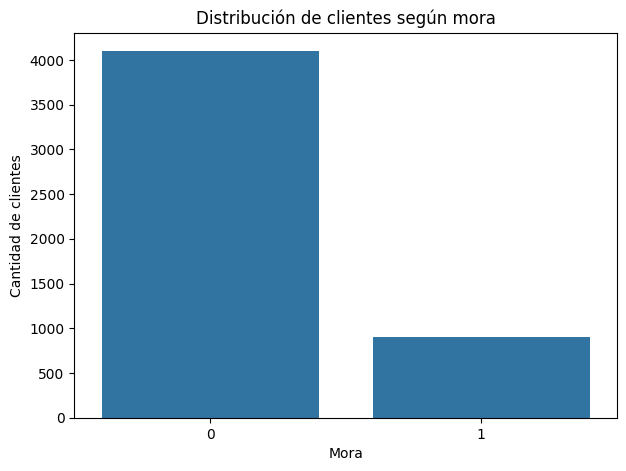

In [26]:
# Gráfico de distribución de la variable mora

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clientes,
    x="mora"
)

plt.title("Distribución de clientes según mora")
plt.xlabel("Mora")
plt.ylabel("Cantidad de clientes")

plt.show()

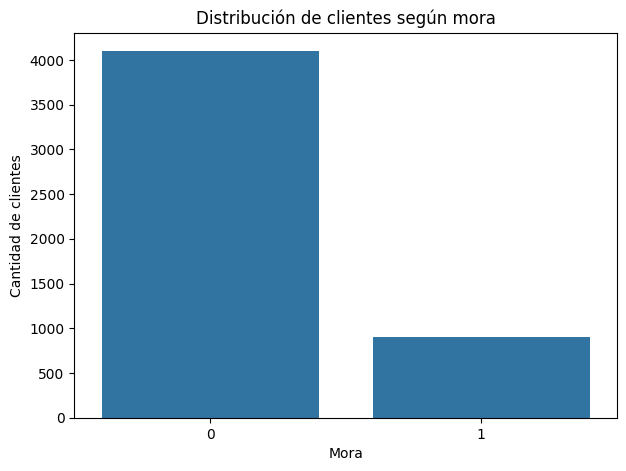

In [27]:
# Gráfico de distribución de la variable mora

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clientes,
    x="mora"
)

plt.title("Distribución de clientes según mora")
plt.xlabel("Mora")
plt.ylabel("Cantidad de clientes")

plt.show()

### Interpretación

La mayoría de los clientes no presentan mora, mientras que una proporción menor sí presenta esta condición.

Esto indica que la variable objetivo no se encuentra completamente balanceada. Por esta razón, al comparar los modelos de clasificación no se utilizará únicamente la exactitud (Accuracy), sino también métricas como Precision, Recall y F1-Score.

## >> Distribución de la edad

Se analiza la distribución de las edades de los clientes para identificar los rangos más frecuentes dentro del conjunto de datos.

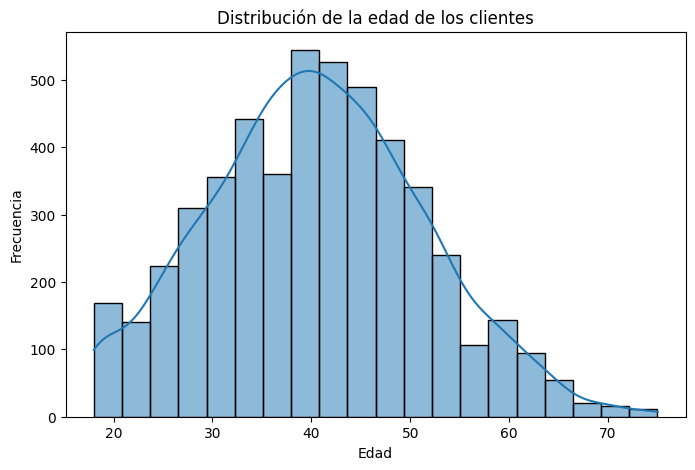

In [28]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clientes,
    x="edad",
    bins=20,
    kde=True
)

plt.title("Distribución de la edad de los clientes")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

### Interpretación

El gráfico permite observar cómo se distribuyen las edades de los clientes del banco y cuáles rangos de edad presentan una mayor frecuencia.

La edad será posteriormente considerada como una posible variable predictora para determinar si existen diferencias en el comportamiento crediticio de los clientes.

## >> Distribución del ingreso mensual

El ingreso mensual representa una de las principales características financieras de los clientes.

Se analiza su distribución para conocer los niveles de ingreso presentes dentro del conjunto de datos.

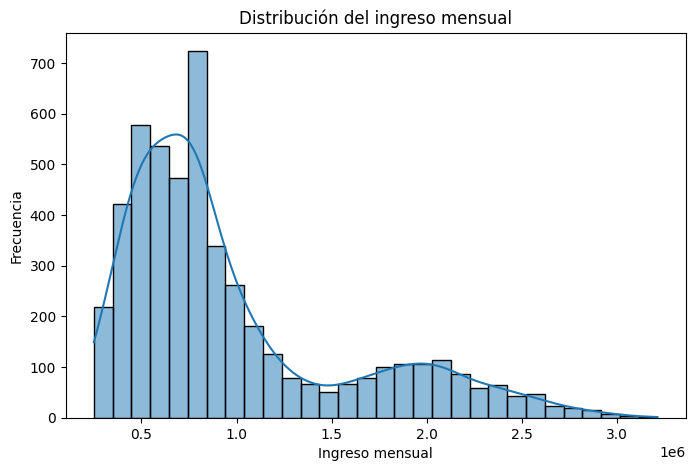

In [29]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clientes,
    x="ingreso_mensual",
    bins=30,
    kde=True
)

plt.title("Distribución del ingreso mensual")
plt.xlabel("Ingreso mensual")
plt.ylabel("Frecuencia")

plt.show()

### Interpretación

El gráfico muestra que existen diferencias importantes entre los niveles de ingreso de los clientes.

También se pueden observar algunos clientes con ingresos considerablemente mayores que el resto, por lo que esta variable presenta cierta dispersión.

El ingreso mensual podría ser una variable relevante al momento de analizar la capacidad financiera y el riesgo crediticio de un cliente.

## >> Distribución de la deuda total

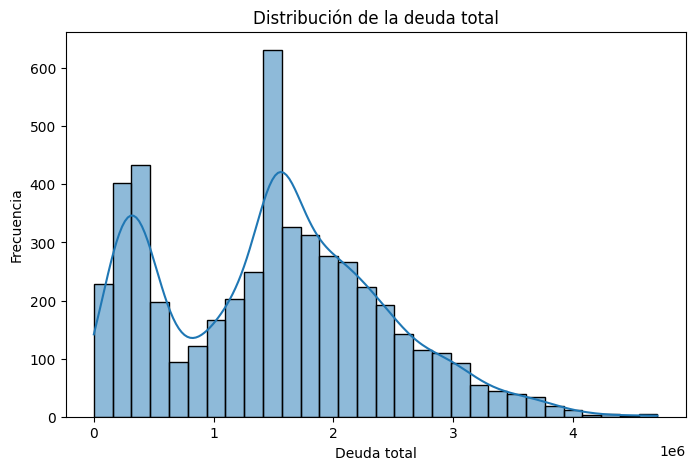

In [30]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clientes,
    x="deuda_total",
    bins=30,
    kde=True
)

plt.title("Distribución de la deuda total")
plt.xlabel("Deuda total")
plt.ylabel("Frecuencia")

plt.show()

### Interpretación

La deuda total presenta una variación considerable entre los clientes.

Esta variable puede ser importante para los modelos de clasificación, ya que niveles elevados de deuda podrían estar relacionados con un mayor riesgo de incumplimiento o mora.

## >> Porcentaje de utilización del crédito

Se analiza el porcentaje de crédito utilizado por los clientes, ya que puede representar un indicador importante de su nivel de endeudamiento.

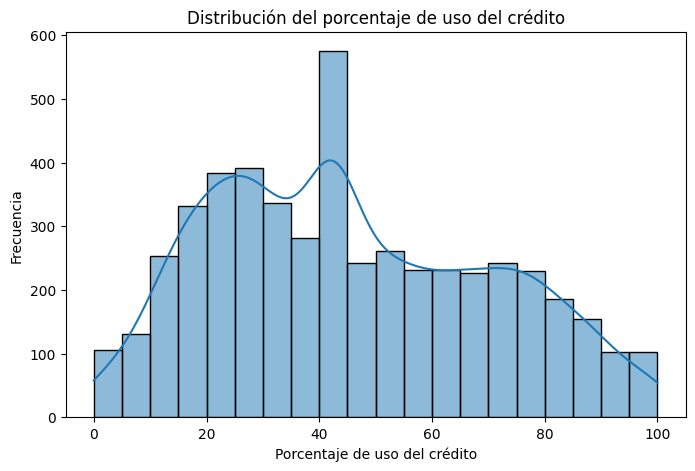

In [31]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clientes,
    x="porcentaje_uso_credito",
    bins=20,
    kde=True
)

plt.title("Distribución del porcentaje de uso del crédito")
plt.xlabel("Porcentaje de uso del crédito")
plt.ylabel("Frecuencia")

plt.show()

## >> Distribución del score crediticio

El score crediticio representa una medida relacionada con el comportamiento y riesgo crediticio de cada cliente.

Se analiza su distribución para conocer los niveles de puntuación presentes en el conjunto de datos.

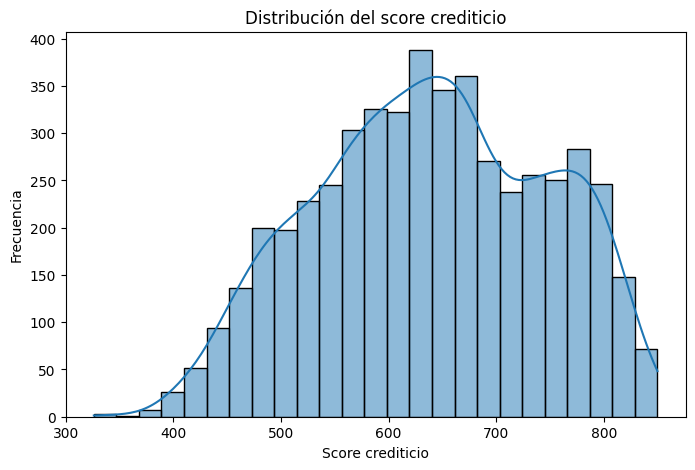

In [32]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clientes,
    x="score_crediticio",
    bins=25,
    kde=True
)

plt.title("Distribución del score crediticio")
plt.xlabel("Score crediticio")
plt.ylabel("Frecuencia")

plt.show()

### Interpretación

El score crediticio presenta diferentes niveles entre los clientes.

Debido a que esta variable refleja información relacionada con el comportamiento crediticio, podría tener una relación importante con la probabilidad de que un cliente presente mora.

# > Análisis de variables respecto a la mora

## >> Score crediticio según mora

Se compara el score crediticio entre los clientes que presentan mora y aquellos que no presentan mora.

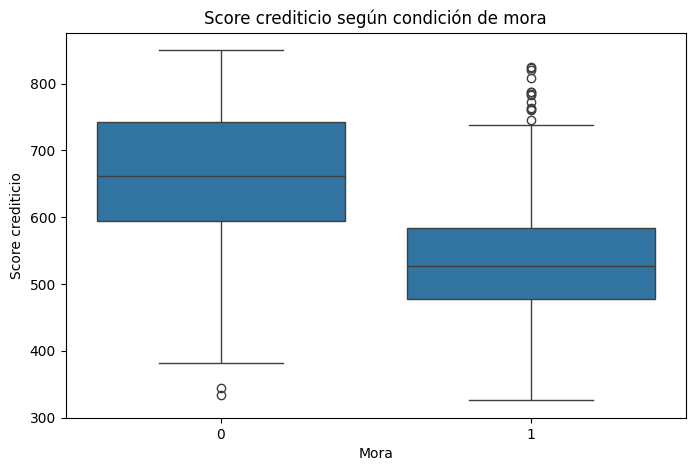

In [33]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clientes,
    x="mora",
    y="score_crediticio"
)

plt.title("Score crediticio según condición de mora")
plt.xlabel("Mora")
plt.ylabel("Score crediticio")

plt.show()

### Interpretación

Este gráfico permite comparar la distribución del score crediticio entre los clientes con mora y sin mora.

Si se observan diferencias entre ambos grupos, esto podría indicar que el score crediticio contiene información útil para ayudar a los modelos de clasificación a identificar clientes con mayor riesgo.

## >> Porcentaje de uso del crédito según mora

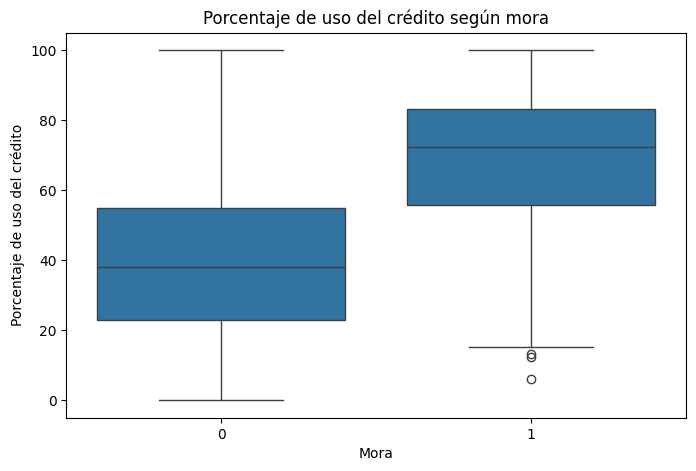

In [34]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clientes,
    x="mora",
    y="porcentaje_uso_credito"
)

plt.title("Porcentaje de uso del crédito según mora")
plt.xlabel("Mora")
plt.ylabel("Porcentaje de uso del crédito")

plt.show()

### Interpretación

La comparación permite determinar si los clientes que presentan mora utilizan una mayor proporción de su crédito disponible.

Esta variable puede representar un indicador de presión financiera y podría contribuir a mejorar la capacidad predictiva de los modelos.

## >> Pagos atrasados históricos según mora

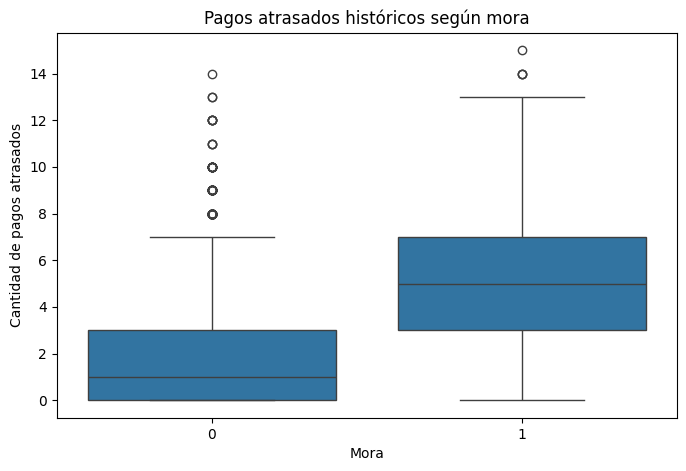

In [35]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clientes,
    x="mora",
    y="cantidad_pagos_atrasados_historicos"
)

plt.title("Pagos atrasados históricos según mora")
plt.xlabel("Mora")
plt.ylabel("Cantidad de pagos atrasados")

plt.show()

### Interpretación

La cantidad de pagos atrasados históricos representa una variable directamente relacionada con el comportamiento de pago de los clientes.

Una mayor cantidad de atrasos podría estar asociada con una mayor probabilidad de presentar mora, por lo que esta característica será considerada durante la construcción de los modelos de clasificación.

# > Análisis de correlación

El análisis de correlación permite conocer el grado de relación existente entre las diferentes variables numéricas.

El coeficiente de correlación puede tomar valores entre -1 y 1:

- Valores cercanos a 1 representan una relación positiva fuerte.
- Valores cercanos a -1 representan una relación negativa fuerte.
- Valores cercanos a 0 representan una relación lineal débil o inexistente.

Se analizará especialmente la relación que presentan las diferentes variables con la variable objetivo `mora`.

In [36]:
# Calcular matriz de correlación

correlacion = df_clientes.corr(numeric_only=True)

correlacion

,edad,ingreso_mensual,antiguedad_cliente_meses,cantidad_tarjetas_activas,deuda_total,porcentaje_uso_credito,cantidad_pagos_atrasados_historicos,score_crediticio,cantidad_productos_bancarios,gasto_mensual_promedio,cantidad_consultas_credito_ultimo_anio,linea_credito_aprobada,mora
edad,1.000000,0.218099,0.329471,0.198546,0.172124,-0.050482,-0.023825,0.132194,0.174674,0.256212,-0.061975,0.164538,-0.022606
ingreso_mensual,0.218099,1.000000,0.561334,0.327586,-0.217878,-0.636794,-0.527447,0.755741,0.343037,0.521555,-0.448661,0.928608,-0.319816
antiguedad_cliente_meses,0.329471,0.561334,1.000000,0.403695,0.208749,-0.252692,-0.194238,0.413463,0.402888,0.562973,-0.235811,0.494999,-0.143778
cantidad_tarjetas_activas,0.198546,0.327586,0.403695,1.000000,0.057795,-0.215703,-0.200851,0.293353,0.259963,0.314802,-0.174447,0.311537,-0.149311
deuda_total,0.172124,-0.217878,0.208749,0.057795,1.000000,0.499548,0.528299,-0.438859,0.060175,0.127584,0.284162,-0.437168,0.302657
porcentaje_uso_credito,-0.050482,-0.636794,-0.252692,-0.215703,0.499548,1.000000,0.675777,-0.754252,-0.220846,-0.270347,0.454325,-0.746539,0.441110
cantidad_pagos_atrasados_historicos,-0.023825,-0.527447,-0.194238,-0.200851,0.528299,0.675777,1.000000,-0.690881,-0.193156,-0.201603,0.424576,-0.677678,0.511817
score_crediticio,0.132194,0.755741,0.413463,0.293353,-0.438859,-0.754252,-0.690881,1.000000,0.301368,0.398999,-0.505895,0.869446,-0.456061
cantidad_productos_bancarios,0.174674,0.343037,0.402888,0.259963,0.060175,-0.220846,-0.193156,0.301368,1.000000,0.326237,-0.159698,0.318821,-0.122159
gasto_mensual_promedio,0.256212,0.521555,0.562973,0.314802,0.127584,-0.270347,-0.201603,0.398999,0.326237,1.000000,-0.208745,0.464994,-0.129897


## >> Matriz de correlación

Se utiliza un mapa de calor para visualizar de manera más clara las relaciones existentes entre las variables.

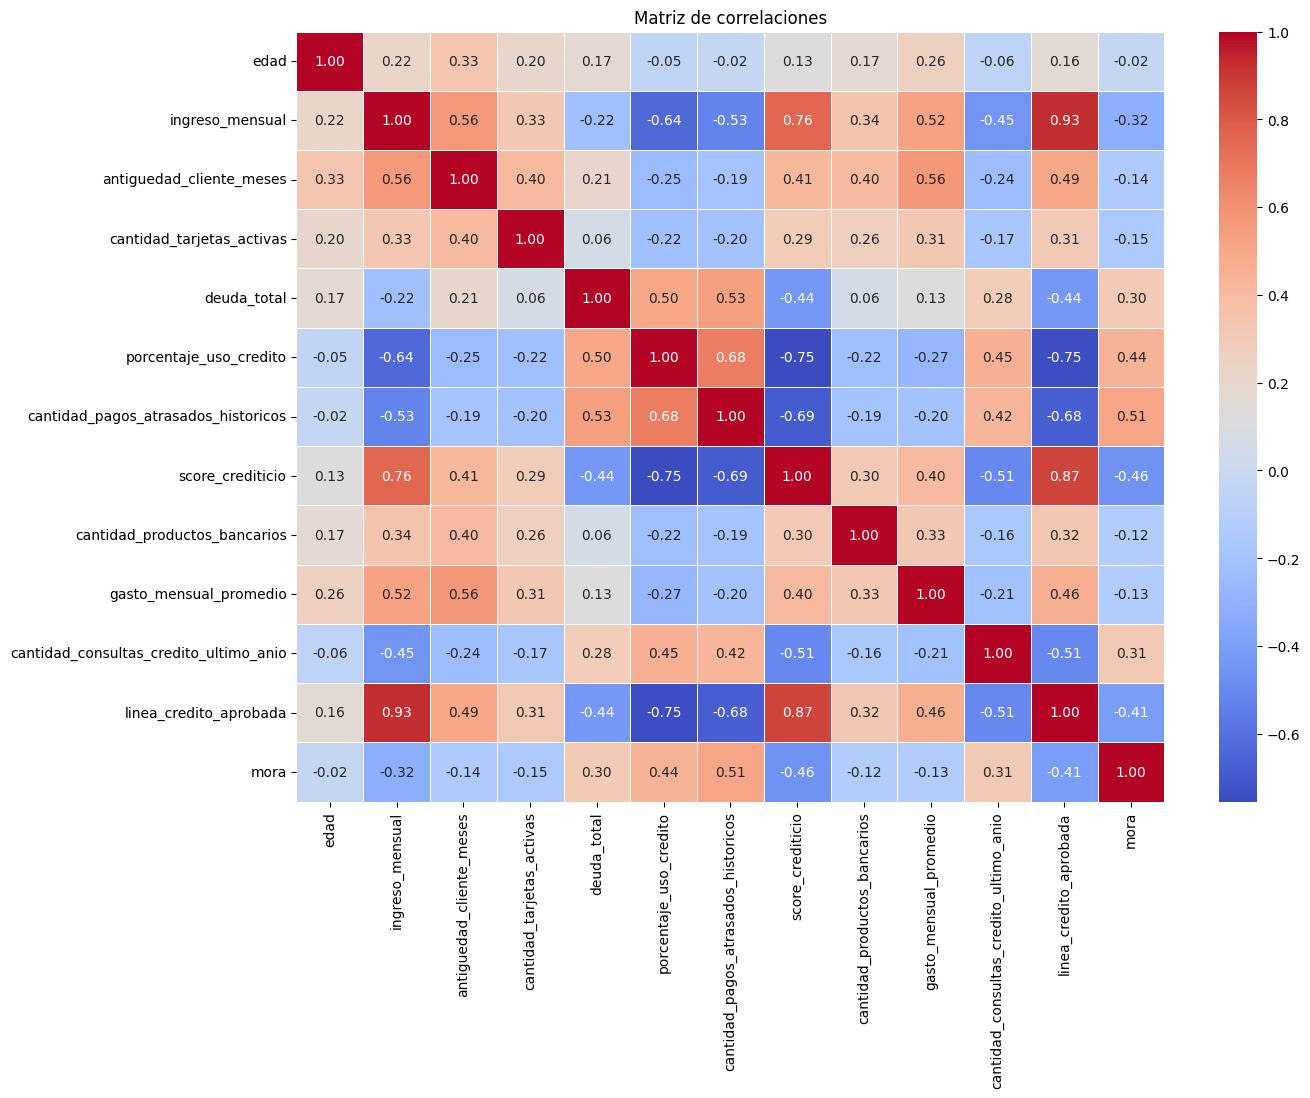

In [37]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de correlaciones")

plt.show()

## >> Correlación de las variables con la mora

Para facilitar la interpretación, se muestran únicamente los coeficientes de correlación de las diferentes variables con la variable objetivo `mora`.

In [38]:
# Correlación de cada variable con mora

correlacion_mora = (
    correlacion["mora"]
    .drop("mora")
    .sort_values(ascending=False)
)

correlacion_mora

,mora
cantidad_pagos_atrasados_historicos,0.511817
porcentaje_uso_credito,0.441110
cantidad_consultas_credito_ultimo_anio,0.308752
deuda_total,0.302657
edad,-0.022606
cantidad_productos_bancarios,-0.122159
gasto_mensual_promedio,-0.129897
antiguedad_cliente_meses,-0.143778
cantidad_tarjetas_activas,-0.149311
ingreso_mensual,-0.319816


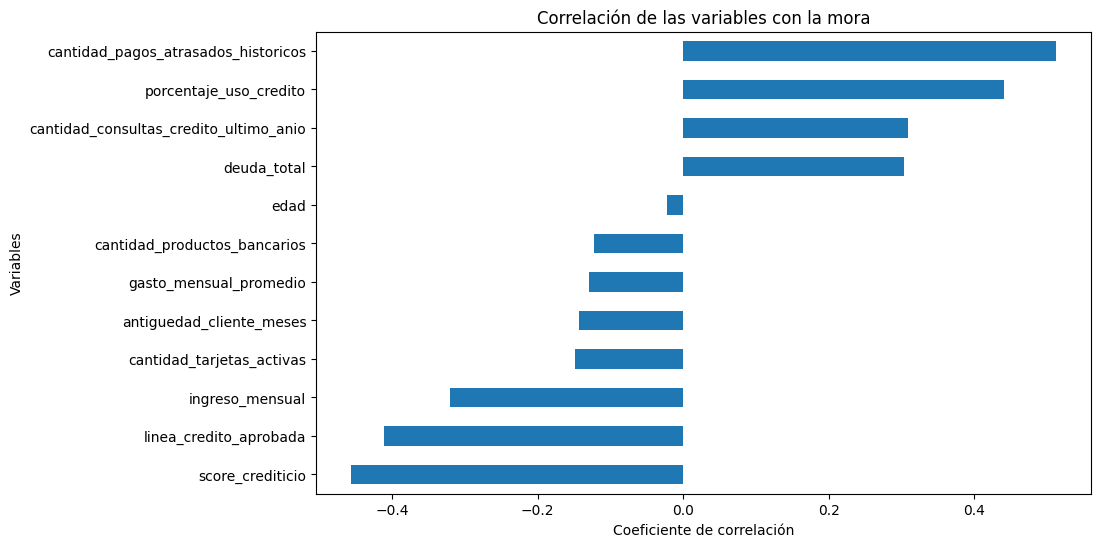

In [39]:
plt.figure(figsize=(10, 6))

correlacion_mora.sort_values().plot(kind="barh")

plt.title("Correlación de las variables con la mora")
plt.xlabel("Coeficiente de correlación")
plt.ylabel("Variables")

plt.show()

### Interpretación del análisis de correlación

La matriz de correlación permite identificar cuáles variables presentan una mayor asociación con la condición de mora.

Las variables que presenten correlaciones positivas con `mora` indican que, conforme aumenta su valor, también podría aumentar la presencia de mora.

Por otro lado, las variables con correlaciones negativas indican que valores mayores podrían estar relacionados con una menor presencia de mora.

Sin embargo, la correlación por sí sola no determina la capacidad predictiva de una variable. Los modelos de Machine Learning permitirán analizar de forma conjunta todas las características y determinar qué tan bien pueden predecir la condición de mora.

# > Preparación para los modelos

Después de realizar la comprensión, limpieza, estadísticas descriptivas, análisis gráfico y análisis de correlación, el conjunto de datos se encuentra preparado para iniciar la etapa de modelado.

En la siguiente sección se desarrollarán dos modelos de clasificación:

1. Regresión Logística.
2. Random Forest.

Ambos modelos serán entrenados utilizando los mismos datos de entrenamiento y prueba para posteriormente comparar sus métricas.

La comparación permitirá seleccionar el modelo que presente el mejor desempeño para realizar la predicción de mora sobre un nuevo cliente.

Posteriormente se desarrollará un modelo de agrupación mediante K-Means para identificar diferentes perfiles de clientes.

# Modelo de Clasificación 1

## Regresión Logística

La Regresión Logística es un algoritmo de aprendizaje supervisado utilizado para problemas de clasificación.

En este proyecto se utilizará para predecir si un cliente presentará mora (1) o no presentará mora (0), utilizando las variables financieras y crediticias disponibles en el conjunto de datos.

Posteriormente este modelo será comparado con Random Forest para determinar cuál presenta un mejor desempeño.

## >> Selección de variables

La variable objetivo será **mora**, mientras que las demás variables serán utilizadas como variables predictoras.

In [40]:
# Variables predictoras

X = df_clientes.drop("mora", axis=1)

# Variable objetivo

y = df_clientes["mora"]

print("Variables predictoras:")
display(X.head())

print("\nVariable objetivo:")
display(y.head())

Variables predictoras:


,edad,ingreso_mensual,antiguedad_cliente_meses,cantidad_tarjetas_activas,deuda_total,porcentaje_uso_credito,cantidad_pagos_atrasados_historicos,score_crediticio,cantidad_productos_bancarios,gasto_mensual_promedio,cantidad_consultas_credito_ultimo_anio,linea_credito_aprobada
0,44,2281997.51,134,3,764332.08,11.25,0,734,2,1331240.76,2,8046000
1,18,582019.75,96,1,1762867.69,51.69,2,538,4,894067.07,5,2429000
2,50,457705.57,39,4,2607589.34,92.45,7,447,1,78899.15,0,1300000
3,42,1951105.56,83,5,1838059.21,32.64,1,818,1,447197.52,1,6905000
4,40,1614834.45,80,3,1767812.29,13.98,0,738,5,284712.77,1,5333000



Variable objetivo:


,mora
0,0
1,0
2,1
3,0
4,0


La variable **mora** será utilizada como la variable a predecir.

Todas las demás variables financieras y crediticias serán utilizadas como variables independientes para entrenar el modelo de clasificación.

## >> División del conjunto de datos

Para evaluar correctamente el desempeño del modelo, el conjunto de datos será dividido en datos de entrenamiento y datos de prueba.

Se utilizará un 80% de los datos para entrenamiento y un 20% para prueba.

In [41]:
# División de datos

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (4000, 12)
Prueba: (1000, 12)


## >> Escalado de los datos

La Regresión Logística es un algoritmo sensible a la escala de las variables.

Por esta razón se utilizará StandardScaler para estandarizar las variables numéricas antes del entrenamiento.

In [42]:
 # Escalar variables

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## >> Entrenamiento del modelo

Una vez preparados los datos, se procede al entrenamiento de la Regresión Logística utilizando el conjunto de entrenamiento.

In [43]:
# Crear modelo

modelo_logistico = LogisticRegression(random_state=42)

# Entrenar modelo

modelo_logistico.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

## >> Predicción

Después del entrenamiento, el modelo realizará predicciones sobre el conjunto de prueba.

In [44]:
# Predicciones

predicciones_log = modelo_logistico.predict(X_test_scaled)

## >> Accuracy

La exactitud (Accuracy) representa el porcentaje de predicciones correctas realizadas por el modelo.

In [45]:
accuracy_log = accuracy_score(y_test, predicciones_log)

print("Accuracy:", round(accuracy_log,4))

Accuracy: 0.854


## >> Precision

La precisión indica qué proporción de los clientes clasificados como morosos realmente presentan mora.

In [46]:
precision_log = precision_score(y_test, predicciones_log)

print("Precision:", round(precision_log,4))

Precision: 0.6214


## >> Recall

El Recall mide la capacidad del modelo para identificar correctamente a los clientes que realmente presentan mora.

In [47]:
recall_log = recall_score(y_test, predicciones_log)

print("Recall:", round(recall_log,4))

Recall: 0.4833


## >> F1-Score

El F1-Score combina Precision y Recall en una única métrica, proporcionando una medida equilibrada del desempeño del modelo.

In [48]:
f1_log = f1_score(y_test, predicciones_log)

print("F1 Score:", round(f1_log,4))

F1 Score: 0.5437


## >> Classification Report

El reporte de clasificación resume las principales métricas obtenidas para cada clase, permitiendo evaluar con mayor detalle el desempeño del modelo.

In [49]:
print(classification_report(y_test, predicciones_log))

              precision    recall  f1-score   support

           0       0.89      0.94      0.91       820
           1       0.62      0.48      0.54       180

    accuracy                           0.85      1000
   macro avg       0.76      0.71      0.73      1000
weighted avg       0.84      0.85      0.85      1000



## >> Matriz de confusión

La matriz de confusión muestra la cantidad de predicciones correctas e incorrectas realizadas por el modelo para cada clase.

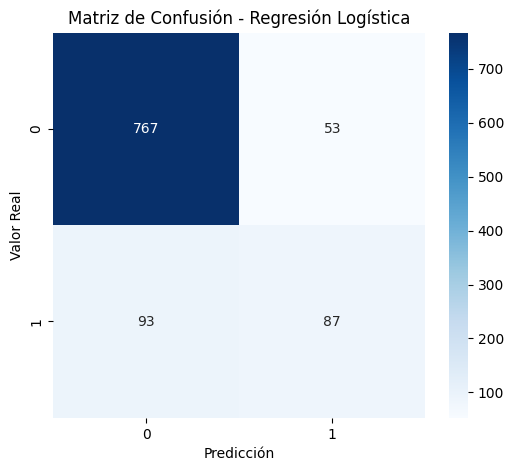

In [50]:
cm = confusion_matrix(y_test, predicciones_log)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión - Regresión Logística")

plt.show()

### Interpretación de resultados

La Regresión Logística fue entrenada utilizando las variables financieras y crediticias disponibles en el conjunto de datos.

Las métricas obtenidas permiten evaluar la capacidad del modelo para identificar correctamente a los clientes que presentan mora y aquellos que no la presentan.

En la siguiente sección se construirá un modelo de Random Forest utilizando exactamente el mismo conjunto de entrenamiento y prueba.

Posteriormente ambos modelos serán comparados utilizando Accuracy, Precision, Recall y F1-Score para seleccionar el algoritmo con mejor desempeño.

# Modelo de Clasificación 2

## Random Forest

Random Forest es un algoritmo de aprendizaje supervisado basado en la combinación de múltiples árboles de decisión.

Cada árbol realiza una predicción y el modelo combina sus resultados para obtener una clasificación final.

En este proyecto se utilizará Random Forest para predecir si un cliente presenta mora o no, utilizando las mismas variables y la misma partición de datos utilizada previamente en la Regresión Logística.

Posteriormente, ambos modelos serán comparados mediante diferentes métricas de evaluación.

## >> Entrenamiento del modelo

Para mantener una comparación justa entre los modelos, Random Forest utilizará el mismo conjunto de entrenamiento y prueba definido anteriormente.

A diferencia de la Regresión Logística, Random Forest no requiere necesariamente que las variables se encuentren escaladas, por lo que se utilizarán los datos originales.

In [51]:
# Crear el modelo Random Forest

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Entrenar el modelo

modelo_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## >> Predicción

Una vez entrenado el modelo, se realizan predicciones utilizando el conjunto de datos de prueba.

In [52]:
# Realizar predicciones

predicciones_rf = modelo_rf.predict(X_test)

## >> Accuracy

La exactitud indica la proporción total de predicciones correctas realizadas por el modelo.

In [53]:
accuracy_rf = accuracy_score(y_test, predicciones_rf)

print("Accuracy:", round(accuracy_rf, 4))

Accuracy: 0.843


## >> Precision

La precisión indica qué proporción de los clientes clasificados por el modelo como clientes con mora realmente pertenecen a esa categoría.

In [54]:
precision_rf = precision_score(y_test, predicciones_rf)

print("Precision:", round(precision_rf, 4))

Precision: 0.5865


## >> Recall

El Recall permite conocer qué proporción de los clientes que realmente presentan mora fueron correctamente identificados por el modelo.

In [55]:
recall_rf = recall_score(y_test, predicciones_rf)

print("Recall:", round(recall_rf, 4))

Recall: 0.4333


## >> F1-Score

El F1-Score combina Precision y Recall en una sola métrica y permite evaluar de forma equilibrada la capacidad de clasificación del modelo.

In [56]:
f1_rf = f1_score(y_test, predicciones_rf)

print("F1 Score:", round(f1_rf, 4))

F1 Score: 0.4984


## >> Classification Report

El reporte de clasificación permite visualizar de forma conjunta Precision, Recall, F1-Score y la cantidad de registros de cada clase.

In [57]:
print(classification_report(y_test, predicciones_rf))

              precision    recall  f1-score   support

           0       0.88      0.93      0.91       820
           1       0.59      0.43      0.50       180

    accuracy                           0.84      1000
   macro avg       0.73      0.68      0.70      1000
weighted avg       0.83      0.84      0.83      1000



## >> Matriz de confusión

La matriz de confusión permite identificar las predicciones correctas e incorrectas realizadas por Random Forest.

Esto permite analizar con mayor detalle la capacidad del modelo para clasificar clientes con mora y sin mora.

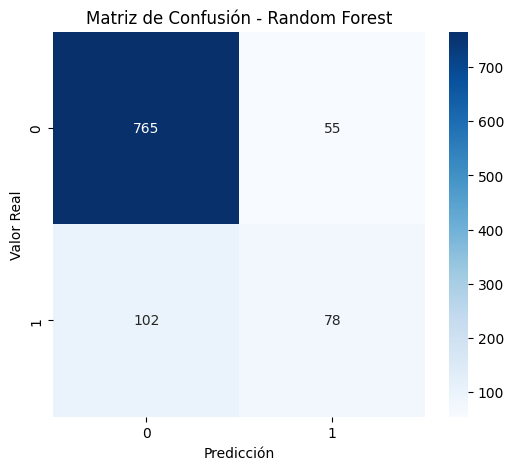

In [58]:
cm_rf = confusion_matrix(y_test, predicciones_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión - Random Forest")

plt.show()

### Interpretación de Random Forest

Random Forest fue entrenado utilizando las mismas variables predictoras y la misma división de entrenamiento y prueba que la Regresión Logística.

Las métricas obtenidas permiten analizar su capacidad para clasificar correctamente a los clientes y, especialmente, su capacidad para identificar a los clientes que realmente presentan mora.

A continuación se compararán los resultados obtenidos por ambos modelos para determinar cuál presenta un mejor desempeño.

# > Competición entre modelos de clasificación

Después de entrenar y evaluar la Regresión Logística y Random Forest, se comparan las principales métricas obtenidas por ambos modelos.

Las métricas utilizadas serán:

- Accuracy
- Precision
- Recall
- F1-Score

Debido a que la variable `mora` presenta una menor cantidad de casos positivos, no se utilizará únicamente Accuracy para seleccionar el mejor modelo.

También se prestará especial atención a Recall y F1-Score, ya que es importante identificar correctamente a los clientes que realmente presentan mora.

In [59]:
# Crear tabla de comparación de métricas

comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_log,
        accuracy_rf
    ],
    "Precision": [
        precision_log,
        precision_rf
    ],
    "Recall": [
        recall_log,
        recall_rf
    ],
    "F1-Score": [
        f1_log,
        f1_rf
    ]
})

comparacion_modelos

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Regresión Logística,0.854,0.621429,0.483333,0.543750
1,Random Forest,0.843,0.586466,0.433333,0.498403


In [60]:
comparacion_modelos_redondeado = comparacion_modelos.copy()

columnas_metricas = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

comparacion_modelos_redondeado[columnas_metricas] = (
    comparacion_modelos_redondeado[columnas_metricas].round(4)
)

comparacion_modelos_redondeado

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Regresión Logística,0.854,0.6214,0.4833,0.5438
1,Random Forest,0.843,0.5865,0.4333,0.4984


## >> Comparación gráfica de los modelos

Se realiza una comparación gráfica de las métricas obtenidas por ambos modelos para facilitar la identificación del modelo con mejor desempeño.

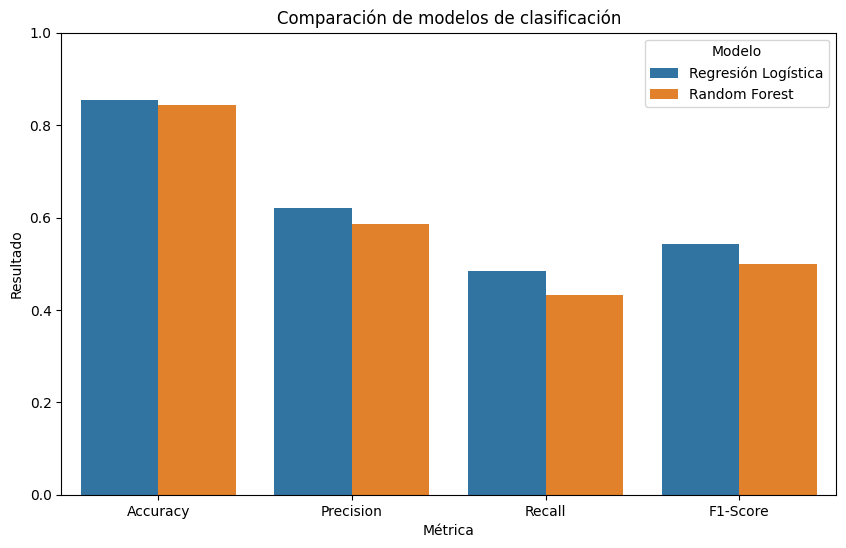

In [61]:
# Preparar los datos para el gráfico

comparacion_grafico = comparacion_modelos.melt(
    id_vars="Modelo",
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparacion_grafico,
    x="Métrica",
    y="Valor",
    hue="Modelo"
)

plt.title("Comparación de modelos de clasificación")
plt.ylabel("Resultado")
plt.xlabel("Métrica")
plt.ylim(0, 1)

plt.legend(title="Modelo")

plt.show()

## >> Selección del modelo

Para seleccionar el modelo que será utilizado posteriormente para realizar la predicción de un nuevo cliente, se utilizará principalmente el F1-Score.

Esta métrica permite considerar de manera conjunta la precisión del modelo y su capacidad para identificar correctamente los casos de mora.

In [62]:
# Seleccionar el modelo con mayor F1-Score

mejor_fila = comparacion_modelos.loc[
    comparacion_modelos["F1-Score"].idxmax()
]

print("Mejor modelo:", mejor_fila["Modelo"])
print("Accuracy:", round(mejor_fila["Accuracy"], 4))
print("Precision:", round(mejor_fila["Precision"], 4))
print("Recall:", round(mejor_fila["Recall"], 4))
print("F1-Score:", round(mejor_fila["F1-Score"], 4))

Mejor modelo: Regresión Logística
Accuracy: 0.854
Precision: 0.6214
Recall: 0.4833
F1-Score: 0.5438


In [63]:
# Guardar el mejor modelo

if f1_rf > f1_log:
    mejor_modelo = modelo_rf
    nombre_mejor_modelo = "Random Forest"
else:
    mejor_modelo = modelo_logistico
    nombre_mejor_modelo = "Regresión Logística"

print("Modelo seleccionado:", nombre_mejor_modelo)

Modelo seleccionado: Regresión Logística


### Interpretación de la competición entre modelos

Se compararon los resultados obtenidos por la Regresión Logística y Random Forest utilizando Accuracy, Precision, Recall y F1-Score.

La selección del mejor modelo se realizó considerando especialmente el F1-Score, debido a que esta métrica permite evaluar de manera equilibrada Precision y Recall.

El modelo que obtuvo el mayor F1-Score será utilizado como modelo definitivo para realizar la predicción de la condición de mora de un nuevo cliente.

La selección no se basa únicamente en Accuracy, ya que es importante que el modelo tenga una buena capacidad para identificar correctamente a los clientes que realmente presentan mora.

# > Importancia de las variables

Random Forest permite identificar qué variables tuvieron una mayor influencia durante el proceso de clasificación.

Este análisis ayuda a comprender cuáles características financieras o crediticias son más relevantes para el modelo.

In [64]:
# Obtener importancia de las variables

importancia_variables = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_rf.feature_importances_
})

importancia_variables = importancia_variables.sort_values(
    by="Importancia",
    ascending=False
)

importancia_variables

,Variable,Importancia
7,score_crediticio,0.147712
5,porcentaje_uso_credito,0.128666
11,linea_credito_aprobada,0.122828
6,cantidad_pagos_atrasados_historicos,0.119017
1,ingreso_mensual,0.101587
4,deuda_total,0.084096
9,gasto_mensual_promedio,0.071312
2,antiguedad_cliente_meses,0.068953
0,edad,0.060670
10,cantidad_consultas_credito_ultimo_anio,0.042909


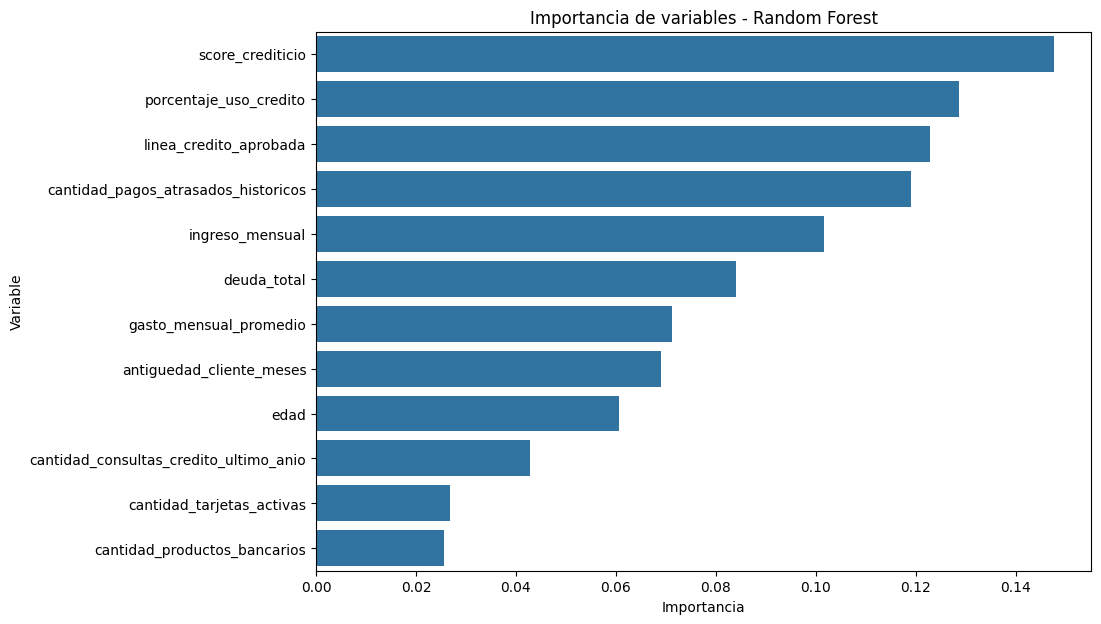

In [65]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=importancia_variables,
    x="Importancia",
    y="Variable"
)

plt.title("Importancia de variables - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")

plt.show()

### Interpretación de la importancia de variables

El gráfico permite identificar cuáles variables tuvieron una mayor participación en las decisiones realizadas por Random Forest.

Las variables con valores de importancia más altos tienen una mayor influencia dentro del modelo para distinguir entre clientes con mora y clientes sin mora.

Este análisis permite complementar los resultados obtenidos previamente en la matriz de correlación.

# Modelo de Agrupación

## K-Means

K-Means es un algoritmo de aprendizaje no supervisado utilizado para agrupar registros que presentan características similares.

A diferencia de los modelos de clasificación, este algoritmo no utiliza una variable objetivo.

En este proyecto se utilizará K-Means para identificar diferentes perfiles de clientes según sus características financieras y crediticias.

## >> Selección de variables

Para el modelo de agrupación se utilizarán variables numéricas relacionadas con el comportamiento financiero y crediticio de los clientes.

No se utilizará la variable `mora`, ya que el objetivo del algoritmo es crear grupos sin conocer previamente una categoría objetivo.

In [66]:
# Selección de variables para agrupación

variables_cluster = [
    "edad",
    "ingreso_mensual",
    "antiguedad_cliente_meses",
    "cantidad_tarjetas_activas",
    "deuda_total",
    "porcentaje_uso_credito",
    "cantidad_pagos_atrasados_historicos",
    "score_crediticio",
    "cantidad_productos_bancarios",
    "gasto_mensual_promedio",
    "cantidad_consultas_credito_ultimo_anio",
    "linea_credito_aprobada"
]

X_cluster = df_clientes[variables_cluster]

X_cluster.head()

,edad,ingreso_mensual,antiguedad_cliente_meses,cantidad_tarjetas_activas,deuda_total,porcentaje_uso_credito,cantidad_pagos_atrasados_historicos,score_crediticio,cantidad_productos_bancarios,gasto_mensual_promedio,cantidad_consultas_credito_ultimo_anio,linea_credito_aprobada
0,44,2281997.51,134,3,764332.08,11.25,0,734,2,1331240.76,2,8046000
1,18,582019.75,96,1,1762867.69,51.69,2,538,4,894067.07,5,2429000
2,50,457705.57,39,4,2607589.34,92.45,7,447,1,78899.15,0,1300000
3,42,1951105.56,83,5,1838059.21,32.64,1,818,1,447197.52,1,6905000
4,40,1614834.45,80,3,1767812.29,13.98,0,738,5,284712.77,1,5333000


## >> Escalado de datos

K-Means utiliza distancias para determinar qué registros son similares.

Debido a que las variables presentan escalas diferentes, es necesario estandarizarlas antes de aplicar el modelo.

In [67]:
# Escalado de las variables

scaler_cluster = StandardScaler()

X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

## >> Método del codo

Antes de entrenar K-Means es necesario seleccionar una cantidad adecuada de clusters.

Para ello se utilizará el método del codo, el cual compara la inercia obtenida utilizando diferentes cantidades de grupos.

Se busca identificar el punto donde la reducción de la inercia comienza a ser menos pronunciada.

In [68]:
# Calcular inercia para diferentes cantidades de clusters

inercias = []

rango_clusters = range(1, 11)

for k in rango_clusters:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_cluster_scaled)

    inercias.append(kmeans.inertia_)

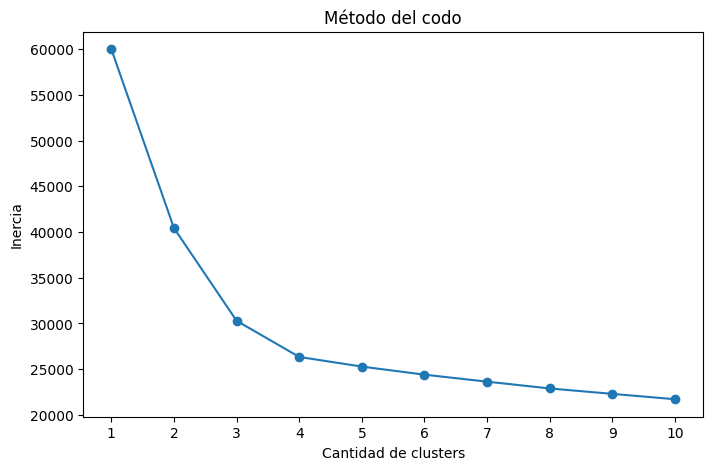

In [69]:
# Gráfico del método del codo

plt.figure(figsize=(8, 5))

plt.plot(
    rango_clusters,
    inercias,
    marker="o"
)

plt.title("Método del codo")
plt.xlabel("Cantidad de clusters")
plt.ylabel("Inercia")

plt.xticks(range(1, 11))

plt.show()

### Interpretación del método del codo

El gráfico permite observar cómo disminuye la inercia a medida que aumenta la cantidad de clusters.

El número de clusters recomendado se encuentra alrededor del punto donde la disminución comienza a ser menos pronunciada.

A partir de este resultado se seleccionará una cantidad adecuada de grupos para continuar con el modelo.

## >> Entrenamiento de K-Means

A partir del método del codo se seleccionan 3 clusters para segmentar a los clientes.

El modelo asignará cada cliente al grupo cuyas características sean más similares.

In [70]:
# Crear y entrenar modelo K-Means

modelo_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = modelo_kmeans.fit_predict(X_cluster_scaled)

## >> Asignación de clusters

Después del entrenamiento, se agrega al conjunto de datos una nueva variable llamada `cluster`, la cual indica el grupo asignado a cada cliente.

In [ ]:
# Agregar cluster al DataFrame

df_clientes["cluster"] = clusters

df_clientes.head()

## >> Distribución de clientes por cluster

Se analiza la cantidad de clientes asignados a cada uno de los grupos generados por K-Means.

In [72]:
df_clientes["cluster"] = clusters
# Cantidad de clientes por cluster

df_clientes["cluster"].value_counts().sort_index()

,count
cluster,
0,1123
1,1371
2,2506


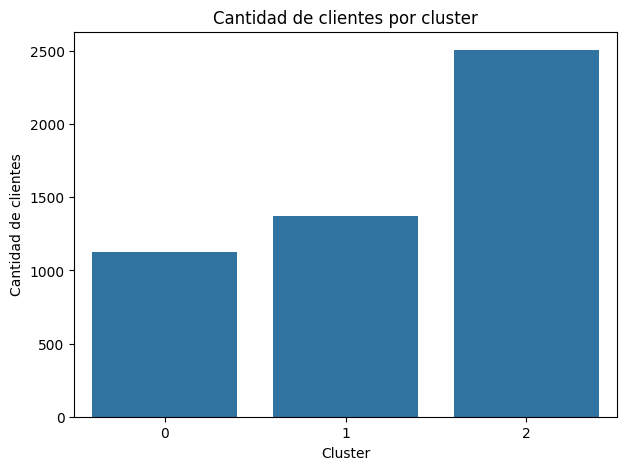

In [73]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clientes,
    x="cluster"
)

plt.title("Cantidad de clientes por cluster")
plt.xlabel("Cluster")
plt.ylabel("Cantidad de clientes")

plt.show()

# > Análisis de los clusters

Para comprender las características de cada grupo se calculará el promedio de las principales variables financieras y crediticias por cluster.

Esto permitirá identificar las diferencias entre los perfiles generados por K-Means.

In [74]:
# Promedios de las variables por cluster

perfil_clusters = df_clientes.groupby("cluster")[variables_cluster].mean()

perfil_clusters.round(2)

,edad,ingreso_mensual,antiguedad_cliente_meses,cantidad_tarjetas_activas,deuda_total,porcentaje_uso_credito,cantidad_pagos_atrasados_historicos,score_crediticio,cantidad_productos_bancarios,gasto_mensual_promedio,cantidad_consultas_credito_ultimo_anio,linea_credito_aprobada
cluster,,,,,,,,,,,,
0,46.99,1933674.36,98.58,3.67,1498850.95,21.19,0.29,778.46,3.86,863215.55,1.04,6861374.89
1,34.28,922653.01,12.79,2.07,431588.85,31.18,0.59,676.10,2.12,316585.62,1.97,4203773.16
2,41.00,573313.95,41.63,2.55,2078300.25,64.29,4.10,556.39,2.58,457506.81,3.48,2074672.39


In [75]:
# Resumen de principales características por cluster

perfil_resumido = df_clientes.groupby("cluster")[
    [
        "ingreso_mensual",
        "deuda_total",
        "porcentaje_uso_credito",
        "cantidad_pagos_atrasados_historicos",
        "score_crediticio",
        "gasto_mensual_promedio",
        "linea_credito_aprobada"
    ]
].mean()

perfil_resumido.round(2)

,ingreso_mensual,deuda_total,porcentaje_uso_credito,cantidad_pagos_atrasados_historicos,score_crediticio,gasto_mensual_promedio,linea_credito_aprobada
cluster,,,,,,,
0,1933674.36,1498850.95,21.19,0.29,778.46,863215.55,6861374.89
1,922653.01,431588.85,31.18,0.59,676.10,316585.62,4203773.16
2,573313.95,2078300.25,64.29,4.10,556.39,457506.81,2074672.39


### Interpretación de los clusters

La tabla permite comparar las principales características financieras y crediticias de los clientes pertenecientes a cada cluster.

Para interpretar los grupos se prestará especial atención a variables como:

- Ingreso mensual.
- Deuda total.
- Porcentaje de uso del crédito.
- Pagos atrasados históricos.
- Score crediticio.
- Gasto mensual promedio.
- Línea de crédito aprobada.

A partir de estos resultados se puede construir un perfil descriptivo para cada grupo.

## >> Visualización de los clusters

Se realizan diferentes gráficos para observar las diferencias entre los grupos creados por el modelo.

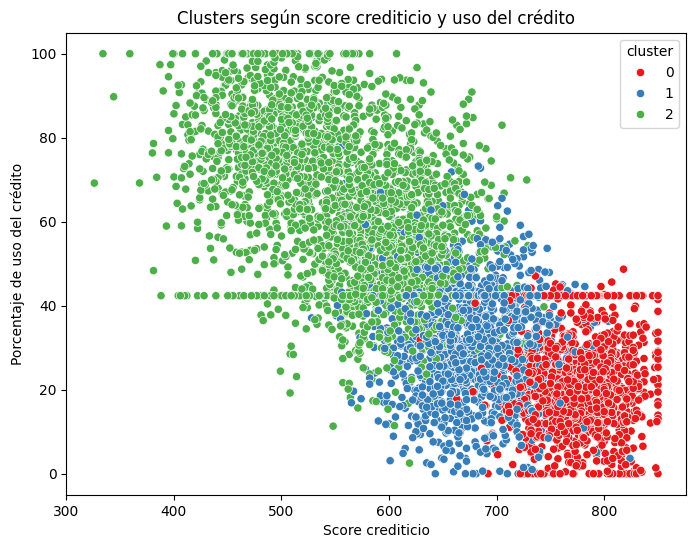

In [76]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_clientes,
    x="score_crediticio",
    y="porcentaje_uso_credito",
    hue="cluster",
    palette="Set1"
)

plt.title("Clusters según score crediticio y uso del crédito")
plt.xlabel("Score crediticio")
plt.ylabel("Porcentaje de uso del crédito")

plt.show()

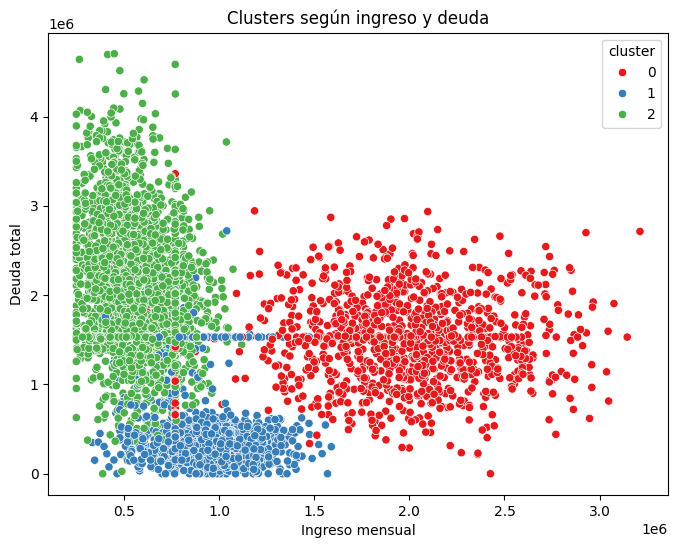

In [77]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_clientes,
    x="ingreso_mensual",
    y="deuda_total",
    hue="cluster",
    palette="Set1"
)

plt.title("Clusters según ingreso y deuda")
plt.xlabel("Ingreso mensual")
plt.ylabel("Deuda total")

plt.show()

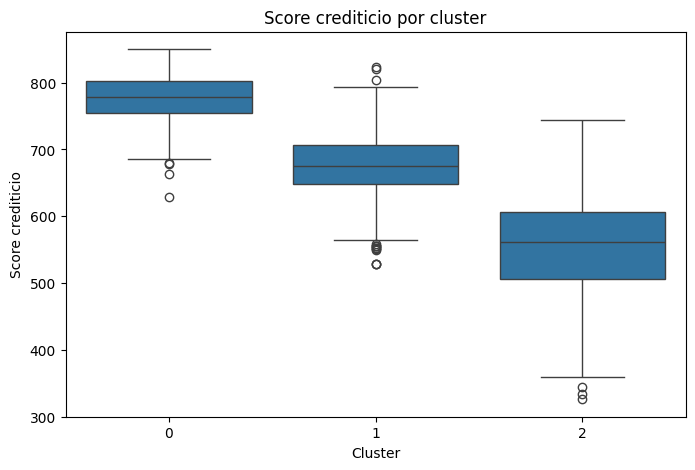

In [78]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clientes,
    x="cluster",
    y="score_crediticio"
)

plt.title("Score crediticio por cluster")
plt.xlabel("Cluster")
plt.ylabel("Score crediticio")

plt.show()

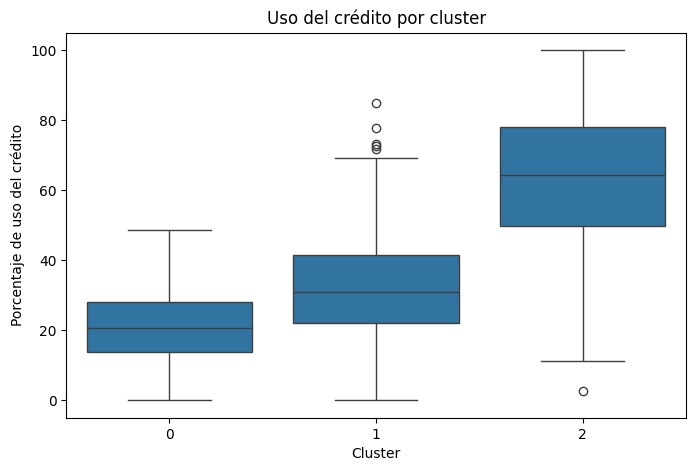

In [79]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clientes,
    x="cluster",
    y="porcentaje_uso_credito"
)

plt.title("Uso del crédito por cluster")
plt.xlabel("Cluster")
plt.ylabel("Porcentaje de uso del crédito")

plt.show()

## >> Relación entre clusters y mora

Aunque la variable `mora` no fue utilizada para entrenar K-Means, se puede analizar posteriormente para conocer qué proporción de clientes en mora existe dentro de cada cluster.

Esto puede ayudar a interpretar el nivel de riesgo de cada grupo.

In [80]:
# Proporción promedio de mora por cluster

mora_cluster = df_clientes.groupby("cluster")["mora"].mean()

mora_cluster

,mora
cluster,
0,0.008905
1,0.047411
2,0.329210


In [81]:
# Convertir proporción a porcentaje

(mora_cluster * 100).round(2)

,mora
cluster,
0,0.89
1,4.74
2,32.92


In [82]:
# Tabla resumen de clusters incluyendo mora

resumen_clusters = df_clientes.groupby("cluster").agg({
    "edad": "mean",
    "ingreso_mensual": "mean",
    "deuda_total": "mean",
    "porcentaje_uso_credito": "mean",
    "cantidad_pagos_atrasados_historicos": "mean",
    "score_crediticio": "mean",
    "gasto_mensual_promedio": "mean",
    "linea_credito_aprobada": "mean",
    "mora": "mean"
})

resumen_clusters["mora_porcentaje"] = (
    resumen_clusters["mora"] * 100
)

resumen_clusters.round(2)

,edad,ingreso_mensual,deuda_total,porcentaje_uso_credito,cantidad_pagos_atrasados_historicos,score_crediticio,gasto_mensual_promedio,linea_credito_aprobada,mora,mora_porcentaje
cluster,,,,,,,,,,
0,46.99,1933674.36,1498850.95,21.19,0.29,778.46,863215.55,6861374.89,0.01,0.89
1,34.28,922653.01,431588.85,31.18,0.59,676.10,316585.62,4203773.16,0.05,4.74
2,41.00,573313.95,2078300.25,64.29,4.10,556.39,457506.81,2074672.39,0.33,32.92


# > Nombre e interpretación de los clusters

Los números asignados por K-Means no representan por sí mismos un nivel de riesgo.

Por esta razón, los nombres de los clusters se definirán a partir de las características promedio observadas en cada grupo.

Se analizarán especialmente el score crediticio, nivel de deuda, uso del crédito, pagos atrasados y porcentaje de mora.

In [83]:
# Asignar nombres descriptivos a los clusters
# IMPORTANTE: ajustar después de revisar resumen_clusters

nombres_clusters = {
    0: "Perfil 1",
    1: "Perfil 2",
    2: "Perfil 3"
}

df_clientes["perfil_cluster"] = df_clientes["cluster"].map(
    nombres_clusters
)

df_clientes[
    [
        "cluster",
        "perfil_cluster",
        "score_crediticio",
        "porcentaje_uso_credito",
        "deuda_total",
        "mora"
    ]
].head()

,cluster,perfil_cluster,score_crediticio,porcentaje_uso_credito,deuda_total,mora
0,0,Perfil 1,734,11.25,764332.08,0
1,2,Perfil 3,538,51.69,1762867.69,0
2,2,Perfil 3,447,92.45,2607589.34,1
3,0,Perfil 1,818,32.64,1838059.21,0
4,0,Perfil 1,738,13.98,1767812.29,0


In [84]:
nombres_clusters = {
    0: "Clientes de bajo riesgo",
    1: "Clientes de riesgo moderado",
    2: "Clientes de mayor riesgo"
}

### Interpretación general del modelo de agrupación

El modelo K-Means permitió segmentar a los clientes en diferentes grupos según sus características financieras y crediticias.

Cada cluster presenta un perfil distinto en variables como ingreso, deuda, uso del crédito, pagos atrasados y score crediticio.

La segmentación permite comprender mejor los diferentes tipos de clientes presentes en el conjunto de datos y puede ser utilizada como apoyo para estrategias de análisis de riesgo y comportamiento financiero.

# > Predicción de un nuevo cliente

Después de comparar los modelos de clasificación y seleccionar el que presenta el mejor desempeño, se realizará una predicción utilizando un cliente nuevo.

También se utilizará el modelo K-Means para determinar a qué cluster o perfil pertenece este nuevo cliente.

El nuevo registro debe contener las mismas variables utilizadas durante el entrenamiento de los modelos.

## >> Creación de un nuevo registro

Se crea un cliente ficticio con diferentes características financieras y crediticias.

Este registro será utilizado únicamente para probar el funcionamiento de los modelos desarrollados.

In [85]:
# Crear un nuevo cliente

nuevo_cliente = pd.DataFrame({
    "edad": [35],
    "ingreso_mensual": [1200000],
    "antiguedad_cliente_meses": [48],
    "cantidad_tarjetas_activas": [2],
    "deuda_total": [750000],
    "porcentaje_uso_credito": [45],
    "cantidad_pagos_atrasados_historicos": [1],
    "score_crediticio": [680],
    "cantidad_productos_bancarios": [3],
    "gasto_mensual_promedio": [450000],
    "cantidad_consultas_credito_ultimo_anio": [2],
    "linea_credito_aprobada": [2500000]
})

nuevo_cliente

,edad,ingreso_mensual,antiguedad_cliente_meses,cantidad_tarjetas_activas,deuda_total,porcentaje_uso_credito,cantidad_pagos_atrasados_historicos,score_crediticio,cantidad_productos_bancarios,gasto_mensual_promedio,cantidad_consultas_credito_ultimo_anio,linea_credito_aprobada
0,35,1200000,48,2,750000,45,1,680,3,450000,2,2500000


### Características del nuevo cliente

El nuevo cliente tiene 35 años, un ingreso mensual de 1.2 millones, una deuda total de 750 mil y utiliza aproximadamente un 45% de su crédito disponible.

También posee un score crediticio de 680 puntos y presenta un pago atrasado histórico.

A continuación se utilizará el modelo seleccionado durante la competición para predecir si este cliente podría presentar mora.

In [86]:
mejor_modelo
nombre_mejor_modelo

'Regresión Logística'

## >> Predicción de mora

Se utiliza el modelo de clasificación que obtuvo el mayor F1-Score durante la comparación.

Dependiendo del modelo seleccionado, se aplicará el mismo proceso de transformación utilizado durante su entrenamiento.

In [87]:
# Realizar predicción con el mejor modelo

if nombre_mejor_modelo == "Regresión Logística":

    # Escalar el nuevo cliente utilizando el scaler entrenado anteriormente
    nuevo_cliente_modelo = scaler.transform(nuevo_cliente)

    # Realizar predicción
    prediccion_nuevo = mejor_modelo.predict(nuevo_cliente_modelo)

else:

    # Random Forest utiliza los datos sin escalado
    prediccion_nuevo = mejor_modelo.predict(nuevo_cliente)

print("Modelo utilizado:", nombre_mejor_modelo)
print("Predicción:", prediccion_nuevo[0])

Modelo utilizado: Regresión Logística
Predicción: 0


## >> Interpretación de la predicción

La predicción generada por el modelo utiliza los siguientes valores:

- **0:** Cliente sin mora.
- **1:** Cliente con mora.

Esto permite utilizar el modelo seleccionado para estimar la condición crediticia de nuevos clientes a partir de sus características financieras.

In [88]:
# Mostrar resultado de manera descriptiva

if prediccion_nuevo[0] == 1:
    resultado_prediccion = "El modelo predice que el cliente PRESENTARÁ MORA."
else:
    resultado_prediccion = "El modelo predice que el cliente NO PRESENTARÁ MORA."

print(resultado_prediccion)

El modelo predice que el cliente NO PRESENTARÁ MORA.


## >> Probabilidad estimada

Además de la clasificación final, se obtiene la probabilidad estimada de que el nuevo cliente pertenezca a cada una de las clases.

In [89]:
# Obtener probabilidades

if nombre_mejor_modelo == "Regresión Logística":
    probabilidades = mejor_modelo.predict_proba(nuevo_cliente_modelo)
else:
    probabilidades = mejor_modelo.predict_proba(nuevo_cliente)

prob_sin_mora = probabilidades[0][0]
prob_mora = probabilidades[0][1]

print("Probabilidad de NO presentar mora:",
      round(prob_sin_mora * 100, 2), "%")

print("Probabilidad de presentar mora:",
      round(prob_mora * 100, 2), "%")

Probabilidad de NO presentar mora: 92.04 %
Probabilidad de presentar mora: 7.96 %


### Interpretación

La probabilidad permite complementar la clasificación realizada por el modelo.

En lugar de observar únicamente si el cliente fue clasificado como 0 o 1, se puede conocer el nivel de confianza que el modelo asigna a cada posible resultado.

# > Agrupación del nuevo cliente

Además de predecir la condición de mora, se utilizará el modelo K-Means para determinar a cuál de los perfiles identificados anteriormente pertenece el nuevo cliente.

Debido a que K-Means fue entrenado utilizando datos estandarizados, será necesario aplicar exactamente el mismo escalado al nuevo registro.

In [90]:
# Seleccionar las mismas variables utilizadas por K-Means

nuevo_cliente_cluster = nuevo_cliente[variables_cluster]

# Escalar utilizando el scaler entrenado para clustering

nuevo_cliente_cluster_scaled = scaler_cluster.transform(
    nuevo_cliente_cluster
)

# Predecir cluster

cluster_nuevo = modelo_kmeans.predict(
    nuevo_cliente_cluster_scaled
)

print("Cluster asignado:", cluster_nuevo[0])

Cluster asignado: 1


In [91]:
nombres_clusters

{0: 'Clientes de bajo riesgo',
 1: 'Clientes de riesgo moderado',
 2: 'Clientes de mayor riesgo'}

In [92]:
# Obtener nombre descriptivo del cluster

perfil_nuevo = nombres_clusters[cluster_nuevo[0]]

print("Cluster:", cluster_nuevo[0])
print("Perfil:", perfil_nuevo)

Cluster: 1
Perfil: Clientes de riesgo moderado


### Interpretación del cluster

El modelo K-Means asignó al nuevo cliente a uno de los perfiles identificados durante el análisis de agrupación.

La asignación depende de la similitud entre sus características financieras y las características de los clientes que conforman cada cluster.

Esto permite complementar la predicción de mora con una segmentación más amplia del comportamiento financiero del cliente.

# > Resultado final del nuevo cliente

Se presenta un resumen con el resultado obtenido mediante el modelo de clasificación y el modelo de agrupación.

In [93]:
# Crear resumen final

resultado_nuevo_cliente = pd.DataFrame({
    "Modelo_Clasificacion": [nombre_mejor_modelo],
    "Prediccion_Mora": [prediccion_nuevo[0]],
    "Probabilidad_Mora": [round(prob_mora * 100, 2)],
    "Cluster": [cluster_nuevo[0]],
    "Perfil": [perfil_nuevo]
})

resultado_nuevo_cliente

,Modelo_Clasificacion,Prediccion_Mora,Probabilidad_Mora,Cluster,Perfil
0,Regresión Logística,0,7.96,1,Clientes de riesgo moderado


# > Conclusiones

En este proyecto se desarrolló un proceso completo de Machine Learning utilizando información financiera y crediticia de clientes bancarios.

Inicialmente se realizó la comprensión y limpieza de los datos, incluyendo la identificación de valores nulos, registros duplicados y tipos de datos. Posteriormente se realizaron estadísticas descriptivas, análisis gráficos y una matriz de correlación para comprender las principales características del conjunto de datos.

Para el problema de clasificación se utilizaron dos modelos:

1. Regresión Logística.
2. Random Forest.

Ambos modelos fueron entrenados utilizando la misma partición de datos de entrenamiento y prueba y posteriormente fueron evaluados mediante Accuracy, Precision, Recall y F1-Score.

La comparación entre los modelos permitió seleccionar el algoritmo con mejor desempeño, considerando especialmente el F1-Score debido a la diferencia existente entre la cantidad de clientes con mora y sin mora.

También se desarrolló un modelo de agrupación utilizando K-Means. Este algoritmo permitió segmentar los clientes en diferentes grupos según sus características financieras y crediticias.

El análisis de los clusters permitió identificar distintos perfiles de clientes y comprender las principales características de cada grupo.

Finalmente, se creó un nuevo registro y se aplicó tanto el modelo de clasificación seleccionado como el modelo de agrupación. De esta forma fue posible obtener una predicción de mora y determinar el perfil al cual pertenece el nuevo cliente.

Los resultados muestran cómo los modelos de Machine Learning pueden ser utilizados para apoyar el análisis del comportamiento financiero, la clasificación del riesgo y la segmentación de clientes.

## >> Modelo seleccionado

Después de comparar las métricas obtenidas por Regresión Logística y Random Forest, se seleccionó **Regresión Logística** como el modelo definitivo de clasificación.

Este modelo obtuvo un **Accuracy de 0.8540**, una **Precision de 0.6214**, un **Recall de 0.4833** y un **F1-Score de 0.5438**, siendo el modelo con el mejor desempeño entre los algoritmos evaluados.

Por esta razón, se consideró el modelo más apropiado para realizar la predicción sobre el nuevo cliente. Además, presentó el mejor equilibrio entre la capacidad para identificar correctamente a los clientes con mora y la precisión de sus predicciones, por lo que fue seleccionado como el modelo final del proyecto.

## >> Conclusión del modelo de agrupación

El modelo K-Means permitió identificar tres perfiles diferentes de clientes con base en sus características financieras y crediticias.

**Cluster 0 – Clientes de bajo riesgo:**  
Este grupo se caracteriza por presentar el mejor perfil financiero. Los clientes tienen un ingreso mensual promedio de **1,933,674**, un **score crediticio promedio de 778.46**, un bajo porcentaje de utilización del crédito (**21.19%**) y muy pocos pagos atrasados (**0.29** en promedio). Además, únicamente el **0.89%** de los clientes de este grupo presenta mora, por lo que se considera el perfil de menor riesgo.

**Cluster 1 – Clientes de riesgo moderado:**  
Los clientes de este grupo presentan un ingreso mensual promedio de **922,653**, un **score crediticio de 676.10** y una utilización del crédito del **31.18%**. Aunque mantienen niveles de deuda relativamente bajos y pocos pagos atrasados (**0.59** en promedio), el porcentaje de clientes en mora aumenta a **4.74%**, por lo que representan un nivel de riesgo intermedio.

**Cluster 2 – Clientes de alto riesgo:**  
Este grupo presenta el perfil financiero más riesgoso. Los clientes tienen el menor ingreso mensual promedio (**573,313**), la deuda promedio más alta (**2,078,300**), un elevado porcentaje de utilización del crédito (**64.29%**) y el mayor número de pagos atrasados (**4.10** en promedio). Además, poseen el **score crediticio más bajo (556.39)** y el porcentaje de mora más alto (**32.92%**), por lo que este grupo representa el mayor nivel de riesgo para la entidad bancaria.

En general, la segmentación obtenida mediante K-Means permitió identificar claramente tres perfiles de clientes con comportamientos financieros diferentes. Estos resultados pueden ser utilizados por la entidad bancaria para diseñar estrategias específicas de otorgamiento de crédito, seguimiento del riesgo y fidelización de clientes según las características de cada grupo.